In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import ICIW_Plots

plt.style.use("ICIWstyle")
plt.rcParams["font.size"] = 7

In [23]:
n_dot_old = np.load(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\Experiments\HSA_004\data\FBA-E-19032025_250ml-min_2bar_250_TotalSystem_composition.npy")
timestamps = np.load(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\Experiments\HSA_004\data\FBA-E-19032025_250ml-min_2bar_250_TotalSystem_times.npy")

n_dot = np.load(r"C:\Users\AlexanderZirn\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_ges_system\RTD_200C_260C_20250328_MS_composition_with_GC.npy").T[:,0:3]
t_source = np.load(r"C:\Users\AlexanderZirn\Nextcloud\PTK_Projekte\Auswertung_FBA\RTD_FBA\RTD_ges_system\RTD_200C_260C_20250328_MS_times_with_GC.npy")

In [24]:
print(n_dot.shape)
print(n_dot_old.shape)

(73403, 3)
(149166, 3)


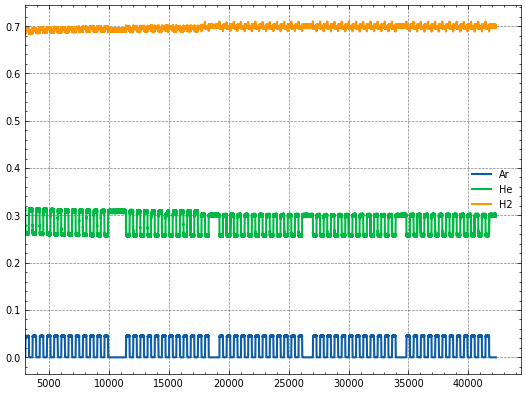

In [25]:
plt.plot(timestamps, n_dot_old[:,0], label="Ar", color="C0")
plt.plot(timestamps, n_dot_old[:,1], label="He", color="C1")
plt.plot(timestamps, n_dot_old[:,2], label="H2", color="C2")
plt.xlim(20.25 + 45 * 60 + 5 * 60,)
plt.legend()

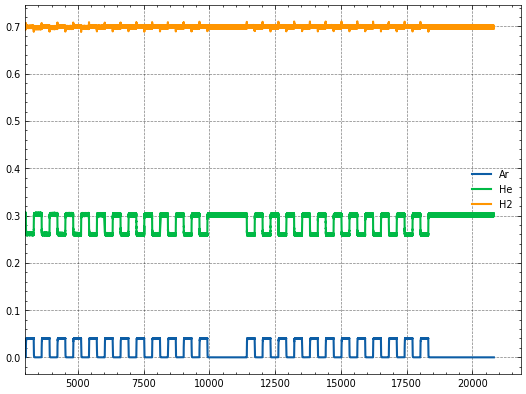

In [26]:
plt.plot(t_source, n_dot[:,0], label="Ar", color="C0")
plt.plot(t_source, n_dot[:,1], label="He", color="C1")
plt.plot(t_source, n_dot[:,2], label="H2", color="C2")
plt.xlim(45*60+5*60,)
plt.legend()

In [27]:
time_delta = t_source - t_source[0]

np.savez(
    "AZA-E-130625_250ml-min_2bar_250_TotalSystem.npz",
    n_dot=n_dot.T,
    time_delta=time_delta,
)

t_range = (time_delta.min(), time_delta.max())

In [28]:
# create array with half-period times

t_offset = 45*60+5*60 # 45min offset until experiment starts
t_halfperiod = 300 # 5min half-period duration

switching_times = np.full((24,), t_halfperiod) # 24 half-periods
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[ 3000  3300  3600  3900  4200  4500  4800  5100  5400  5700  6000  6300
  6600  6900  7200  7500  7800  8100  8400  8700  9000  9300  9600  9900
 10200]
[(np.int64(3000), np.int64(3300)), (np.int64(3300), np.int64(3600)), (np.int64(3600), np.int64(3900)), (np.int64(3900), np.int64(4200)), (np.int64(4200), np.int64(4500)), (np.int64(4500), np.int64(4800)), (np.int64(4800), np.int64(5100)), (np.int64(5100), np.int64(5400)), (np.int64(5400), np.int64(5700)), (np.int64(5700), np.int64(6000)), (np.int64(6000), np.int64(6300)), (np.int64(6300), np.int64(6600)), (np.int64(6600), np.int64(6900)), (np.int64(6900), np.int64(7200)), (np.int64(7200), np.int64(7500)), (np.int64(7500), np.int64(7800)), (np.int64(7800), np.int64(8100)), (np.int64(8100), np.int64(8400)), (np.int64(8400), np.int64(8700)), (np.int64(8700), np.int64(9000)), (np.int64(9000), np.int64(9300)), (np.int64(9300), np.int64(9600)), (np.int64(9600), np.int64(9900)), (np.int64(9900), np.int64(10200))]


In [29]:
print(time_delta.shape)
print(n_dot.shape)

(73403,)
(73403, 3)


In [30]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot.T,
    kind="linear",
    fill_value="extrapolate",
)

In [31]:
t = np.linspace(*t_range, 481)
n_dot_interp = interp(t)

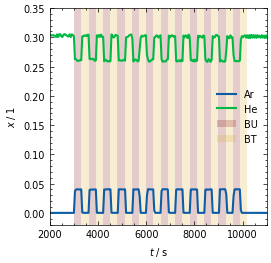

In [32]:
fig = plt.figure()
ax = ICIW_Plots.make_square_ax(
    fig=fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    xlabel="$t\;/\;\mathrm{s}$",
    ylabel="$x\;/\; 1$",
    xlim=(2000, 11000),
    ylim=(-0.02, 0.35),
)
ax.grid(False)
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")


for interval in intervals[::2]:
    plt.fill_betweenx(
        [-0.1, 0.4],
        interval[0],
        interval[1],
        alpha=0.2,
        color="maroon",
        edgecolor=None,
        zorder=-1,
        label="BU",
    )
for interval in intervals[1::2]:
    plt.fill_betweenx(
        [-0.1, 0.4],
        interval[0],
        interval[1],
        alpha=0.2,
        color="goldenrod",
        edgecolor=None,
        zorder=-1,
        label="BT",
    )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.savefig("exp_data_with_halfperiods.png", dpi=600)

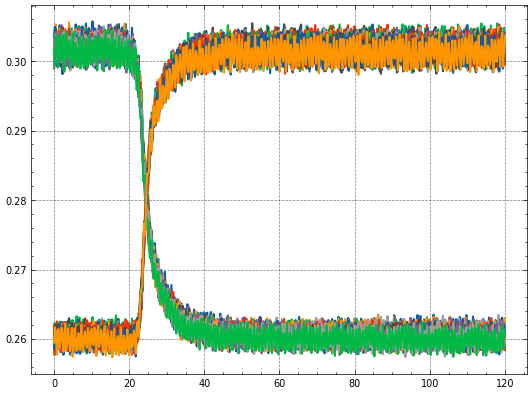

In [33]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 120, 480 + 1)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[1])

In [34]:
%pip install torch
%pip install lightning

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\AlexanderZirn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\AlexanderZirn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
### Constants
# givens
t_out = (0.0, 120.0)
print(f"t_out: {t_out}")
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
print(f"n_out: {n_out}")
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)
print(f"delta_t_out: {delta_t_out}")
# # the capillary times
# # FBA_18032025_300ml-min_Analytik_MS
# switching_periods = np.array(
#     [
#         5 * 60 + 0.03,
#         5 * 60 + 0.27,
#         5 * 60 + 0.27,
#         5 * 60 + 0.28,
#         5 * 60 + 0.18,
#         5 * 60 + 0.26,
#         5 * 60 + 0.33,
#         5 * 60 + 0.27,
#         5 * 60 + 0.18,
#         5 * 60 + 0.05,
#     ]
# )
# switching_times_cap = np.flip(np.cumsum(-switching_periods))
# switching_times_cap = np.append(switching_times_cap, 0) - 1

# the piping times
t_halfperiod = t_out[1] - t_out[0]
print(f"t_halfperiod: {t_halfperiod}")

# automated_switching_times = np.full((20,), t_halfperiod)
# switching_times_reac_inlet = np.insert(automated_switching_times, 0, 7.4 - 1.0)
# switching_times_reac_inlet = np.cumsum(switching_times_reac_inlet)
# switching_times_reac_outlet = np.insert(automated_switching_times, 0, 7.5 - 1.0)
# switching_times_reac_outlet = np.cumsum(switching_times_reac_outlet)
# switching_times_total_system = np.insert(automated_switching_times, 0, 7.7 - 1.0)
# switching_times_total_system = np.cumsum(switching_times_total_system)

t_kernels = [
    #(0.0, 30.0),  # piping to reactor inlet
    #(0.0, 40.0),  # reactor
    (0.0, 30.0)#,  # piping after reactor outlet
    #(0.0, 30.0),  # capillary
]
print(f"t_kernels: {t_kernels}")

n_kernels = list(
    map(
        lambda t_kernel: int(((t_kernel[1] - t_kernel[0]) / delta_t_out) + 1), t_kernels
    )
)
print(f"n_kernels: {n_kernels}")
t_in = (0, t_out[1] - sum([t_kernel[1] for t_kernel in t_kernels]))
print(f"t_in: {t_in}")
n_in = int(((t_in[1] - t_in[0]) / delta_t_out) + 1)
print(f"n_in: {n_in}")



# create array with half-period times

t_offset = 45*60+5*60 # 45min offset until experiment starts
t_halfperiod = 300 # 5min half-period duration

switching_times = np.full((24,), t_halfperiod) # 24 half-periods
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]


t_out: (0.0, 120.0)
n_out: 481
delta_t_out: 0.25
t_halfperiod: 120.0
t_kernels: [(0.0, 30.0)]
n_kernels: [121]
t_in: (0, 90.0)
n_in: 361
[ 3000  3300  3600  3900  4200  4500  4800  5100  5400  5700  6000  6300
  6600  6900  7200  7500  7800  8100  8400  8700  9000  9300  9600  9900
 10200]


In [36]:
import sys

sys.path.append(r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting import RTDDataModule

data_total_system = RTDDataModule(
    batch_size= 32, # 2 temperatures, 2 half-periods, 4 different capillary positions
    data_file=Path(
        r"C:\Users\AlexanderZirn\Documents\GIT\nRTD\Experiments\AZA_001\D - downstream\AZA-E-130625_250ml-min_2bar_250_TotalSystem.npz"
    ),
    switching_times=switching_times,
    # t_range_in=(0, 10), # kernel discretization
    # n_in=41, # kernel
    # t_range_out=(0, 120), # time range of output time series
    # n_out=481,  # number of points in output time series in s (4 MS measurements per second)
    
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    
    switch_delay=1.0,
)

In [37]:
data_total_system.setup("fit")
data_total_system.x[0]

tensor([[2.8212e-05, 2.8212e-05, 2.8212e-05, 2.8212e-05, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02, 4.0078e-02,
         4.0078e-02, 4.0078e

In [38]:
print(data_total_system.x.shape) # 48 = 3 * 16, 3 components

torch.Size([48, 1, 361])


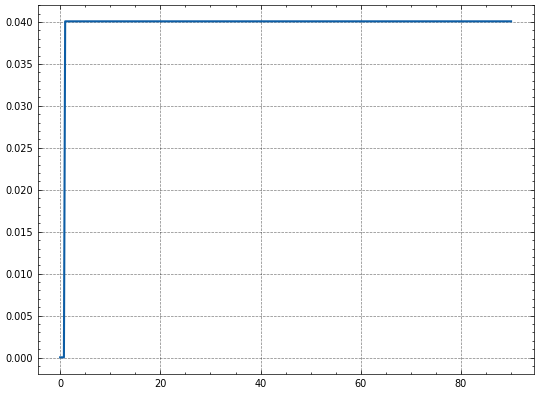

In [39]:
%matplotlib inline
plt.plot(data_total_system.t_in[0,:], data_total_system.x[0,0,:])
plt.show()
plt.close()

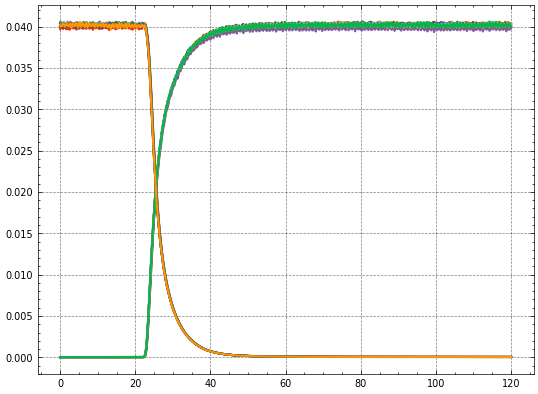

In [40]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,48):
    if i %2==0:
        plt.plot(data_total_system.t_out[i, :], data_total_system.y[i, 0, ...], label="Ar")
plt.show()
plt.close()

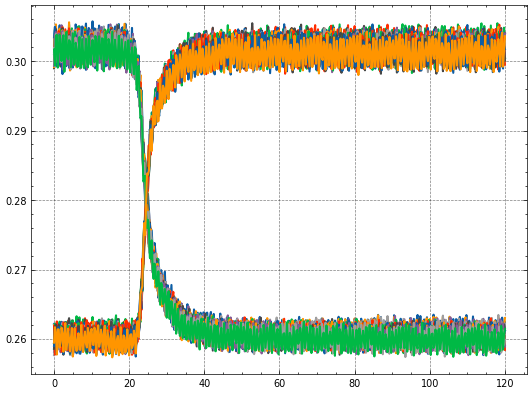

In [41]:
# plot t_in über x
%matplotlib inline
plt.figure()

for i in np.arange(0,48):
    if not i %2==0:
        plt.plot(data_total_system.t_out[i, :], data_total_system.y[i, 0, ...], label="He")
plt.show()
plt.close()

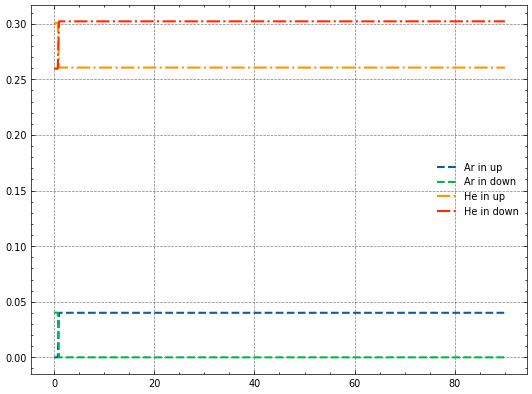

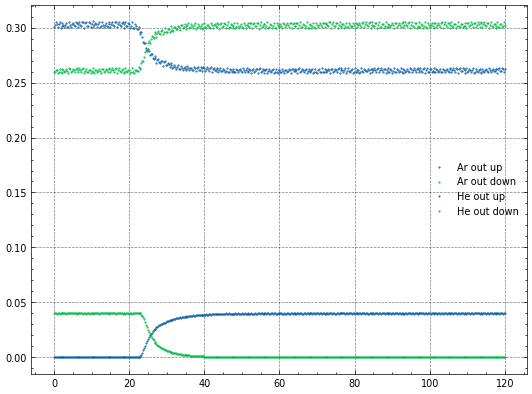

In [42]:
%matplotlib notebook
%matplotlib inline

fig = plt.figure()
index = 0
plt.plot(
    data_total_system.t_in[index],
    data_total_system.x[index].squeeze(),
    ls="--", label ='Ar in up'
)
plt.plot(
    data_total_system.t_in[index + 2],
    data_total_system.x[index + 2].squeeze(),
    ls="--", label = 'Ar in down'
)
plt.plot(
    data_total_system.t_in[index+1],
    data_total_system.x[index+1].squeeze(),
    ls="-.", label ='He in up'
)
plt.plot(
    data_total_system.t_in[index + 3],
    data_total_system.x[index + 3].squeeze(),
    ls="-.", label ='He in down'
)
plt.legend()
plt.show()


plt.plot(
    data_total_system.t_out[index],
    data_total_system.y[index].squeeze(),
    "o",
    c="C0",
    markersize=0.5, label ='Ar out up'
)
plt.plot(
    data_total_system.t_out[index + 2],
    data_total_system.y[index + 2].squeeze(),
    "o",
    c="C1",
    markersize=0.5, label ='Ar out down'
)
plt.plot(
    data_total_system.t_out[index+1],
    data_total_system.y[index+1].squeeze(),
    "o",
    c="C0",
    markersize=0.5, label ='He out up'
)
plt.plot(
    data_total_system.t_out[index + 3],
    data_total_system.y[index + 3].squeeze(),
    "o",
    c="C1",
    markersize=0.5, label ='He out down'
)
plt.legend()
plt.show()